# What Does Yelp Actually Reward? Decoding the Signals Behind Restaurant Ratings

**Author:** [Your Name]  
**Dataset:** [Yelp Open Dataset](https://www.yelp.com/dataset) — 150,000+ business records  
**Notebook Purpose:** Portfolio project — platform signal analysis & ML classification

---

## The Question

Yelp ratings are widely used as a proxy for restaurant quality — by consumers, by competitors, and increasingly by platforms themselves to rank search results. But what if ratings don't primarily reflect quality? What if they reflect *engagement* — how visible a restaurant is, how often customers interact with it, and whether it operates during the hours people actually want it?

This project investigates that question using Yelp's own open dataset. Specifically, I ask:

> **Do platform-level signals (review volume, operating hours, delivery availability) predict high ratings as well as — or better than — physical amenities (parking, WiFi, outdoor seating)?**

The answer has real implications for how platforms surface recommendations and whether ratings are a reliable quality signal at all.

## Analytical Approach

I build a binary classification pipeline to predict whether a restaurant achieves a **high rating (≥ 3.5 stars)** — the threshold at which Yelp's algorithm begins prominently featuring businesses in search results, making it a meaningful business threshold, not just a statistical one.

I test three model families (Logistic Regression, Random Forest, XGBoost) and include a deliberate **sensitivity analysis**: running the best models with and without geographic coordinates (latitude/longitude) to isolate how much predictive power comes from location alone versus platform-level signals.

## Structure
1. Data Loading & Cleaning
2. Exploratory Data Analysis
3. Benchmark Models
4. Main Models: Logistic Regression → Random Forest → XGBoost
5. Sensitivity Analysis: Geographic vs. Platform Signals
6. Platform Implications

## 1. Setup & Data Loading

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import ast
import re
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_score, recall_score, f1_score, make_scorer
)

# ── Models ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from collections import Counter

RANDOM_STATE = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


### Load Data

The dataset is sourced from the [Yelp Open Dataset](https://www.yelp.com/dataset), flattened from nested JSON into a tabular CSV. The original JSON contains 150,246 business records across 11 metropolitan areas. Place `business.csv` in the same directory as this notebook before running.

In [3]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [4]:
# Load the flattened Yelp business dataset
# Source: https://www.yelp.com/dataset (academic use)
business_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Q2/ML Project /business.csv')

print(f'Dataset shape: {business_df.shape}')
print(f'Columns: {business_df.shape[1]}')
business_df.head(3)

Dataset shape: (150346, 60)
Columns: 60


,attributes.BestNights,city,hours.Wednesday,attributes.RestaurantsReservations,attributes.Alcohol,attributes.RestaurantsGoodForGroups,attributes.BusinessParking,latitude,review_count,attributes.AcceptsInsurance,...,attributes.BikeParking,attributes,longitude,state,attributes.Smoking,business_id,name,attributes.RestaurantsTakeOut,attributes.GoodForMeal,hours.Sunday
0,NaN,Santa Barbara,NaN,NaN,NaN,NaN,NaN,34.426679,7,NaN,...,NaN,{'ByAppointmentOnly': 'True'},-119.711197,CA,NaN,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ",NaN,NaN,NaN
1,NaN,Affton,8:0-18:30,NaN,NaN,NaN,NaN,38.551126,15,NaN,...,NaN,{'BusinessAcceptsCreditCards': 'True'},-90.335695,MO,NaN,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,NaN,NaN,NaN
2,NaN,Tucson,8:0-22:0,False,NaN,NaN,"{'garage': False, 'street': False, 'validated'...",32.223236,22,NaN,...,True,"{'BikeParking': 'True', 'BusinessAcceptsCredit...",-110.880452,AZ,NaN,tUFrWirKiKi_TAnsVWINQQ,Target,False,NaN,8:0-22:0


## 2. Data Cleaning & Feature Engineering

The raw dataset has 60 columns with significant missingness. The cleaning strategy has three goals:

1. **Select signal-relevant features** — focus on attributes a business can control or that reflect platform engagement, not arbitrary metadata
2. **Handle missingness explicitly** — fill then filter, rather than silently dropping rows early
3. **Engineer interpretable features** — convert nested structures (parking dict, hour strings) into clean numerics

The **target variable** is `high_rating` (1 if stars ≥ 3.5, else 0). This threshold is meaningful because 3.5 stars is the point at which Yelp's search algorithm begins surfacing businesses prominently — it is a platform-defined boundary, not just a statistical split.

In [5]:
# ── Column Selection ─────────────────────────────────────────────────────────
keep_vars = [
    'stars', 'review_count', 'city', 'state', 'is_open', 'categories',
    'attributes.BusinessParking', 'attributes.RestaurantsTakeOut',
    'attributes.RestaurantsPriceRange2', 'attributes.HasTV',
    'attributes.WiFi', 'attributes.OutdoorSeating',
    'attributes.RestaurantsDelivery', 'attributes.GoodForKids',
    'hours.Monday', 'hours.Tuesday', 'hours.Wednesday', 'hours.Thursday',
    'hours.Friday', 'hours.Saturday', 'hours.Sunday',
    'latitude', 'longitude'
]

filtered_df = business_df[keep_vars].copy()

# ── Target Variable ──────────────────────────────────────────────────────────
filtered_df['high_rating'] = (filtered_df['stars'] >= 3.5).astype(int)

# ── Fill Missing Values ──────────────────────────────────────────────────────
categorical_cols = [
    'city', 'state', 'categories', 'attributes.BusinessParking',
    'attributes.RestaurantsTakeOut', 'attributes.RestaurantsPriceRange2',
    'attributes.HasTV', 'attributes.WiFi', 'attributes.OutdoorSeating',
    'attributes.RestaurantsDelivery', 'attributes.GoodForKids'
]
for col in categorical_cols:
    filtered_df[col] = filtered_df[col].fillna('Unknown')

numeric_cols = [
    'stars', 'review_count', 'is_open',
    'hours.Monday', 'hours.Tuesday', 'hours.Wednesday', 'hours.Thursday',
    'hours.Friday', 'hours.Saturday', 'hours.Sunday',
    'latitude', 'longitude'
]
for col in numeric_cols:
    filtered_df[col] = filtered_df[col].fillna(0)

# ── Drop rows where any key attribute is Unknown ─────────────────────────────
# Rationale: models trained on 'Unknown' placeholders learn noise, not signal
df_clean = filtered_df[~filtered_df.isin(['Unknown']).any(axis=1)].copy()

# ── Boolean Conversion ───────────────────────────────────────────────────────
bool_cols = [
    'attributes.RestaurantsTakeOut', 'attributes.HasTV',
    'attributes.WiFi', 'attributes.OutdoorSeating',
    'attributes.RestaurantsDelivery', 'attributes.GoodForKids', 'is_open'
]
for col in bool_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: 1 if str(x).strip().lower() == 'true' else 0
    )

# ── Operating Hours Engineering ──────────────────────────────────────────────
# Convert 'HH:MM-HH:MM' strings into numeric hours open per day
def hours_open(row):
    if row == '0' or row == 0 or pd.isnull(row):
        return 0
    match = re.match(r'(\d+):(\d+)-(\d+):(\d+)', str(row).replace(' ', ''))
    if match:
        start_h, start_m, end_h, end_m = map(int, match.groups())
        open_minutes = ((end_h * 60 + end_m) - (start_h * 60 + start_m)) % (24 * 60)
        return open_minutes / 60.0
    return 0

hour_cols = [
    'hours.Monday', 'hours.Tuesday', 'hours.Wednesday', 'hours.Thursday',
    'hours.Friday', 'hours.Saturday', 'hours.Sunday'
]
for col in hour_cols:
    df_clean[col] = df_clean[col].apply(hours_open)

df_clean['hours_per_week'] = df_clean[hour_cols].sum(axis=1)

# ── Parking Feature ──────────────────────────────────────────────────────────
# Flatten nested dict to binary: does any parking exist?
def has_parking(x):
    try:
        parking_dict = ast.literal_eval(x)
        return int(any(parking_dict.values()))
    except:
        return 0

df_clean['has_parking'] = df_clean['attributes.BusinessParking'].apply(has_parking)
df_clean.drop(columns=['attributes.BusinessParking'], inplace=True)

# ── City Binning ─────────────────────────────────────────────────────────────
# 1,400+ unique cities creates high cardinality; retain top 10, group rest as 'Other'
top_cities = df_clean['city'].value_counts().nlargest(10).index
df_clean['city'] = df_clean['city'].apply(lambda x: x if x in top_cities else 'Other')

print(f'Clean dataset shape: {df_clean.shape}')
print(f'High rating prevalence: {df_clean["high_rating"].mean():.2%}')
df_clean.head(3)

Clean dataset shape: (27622, 25)
High rating prevalence: 68.72%


,stars,review_count,city,state,is_open,categories,attributes.RestaurantsTakeOut,attributes.RestaurantsPriceRange2,attributes.HasTV,attributes.WiFi,...,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday,latitude,longitude,high_rating,hours_per_week,has_parking
8,3.0,19,Other,MO,0,"Pubs, Restaurants, Italian, Bars, American (Tr...",1,1.0,1,0,...,0.0,0.0,0.0,0.0,0.0,38.565165,-90.321087,0,0.0,1
9,1.5,10,Nashville,TN,0,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",1,1.0,1,0,...,15.0,10.0,10.0,11.0,15.0,36.208102,-86.768170,0,76.0,0
12,2.5,28,Indianapolis,IN,0,"American (Traditional), Restaurants, Diners, B...",1,1.0,1,0,...,16.0,16.0,16.0,16.0,16.0,39.637133,-86.127217,0,112.0,1


## 3. Exploratory Data Analysis

Before modeling, I want to understand three things: how balanced the target variable is, whether any numeric features are strongly correlated with rating, and whether the categorical amenity features show visible separation between high and low-rated businesses.

A key expectation going in: if the platform-signal hypothesis holds, we should see **review_count** showing stronger separation than amenity features like WiFi or parking.

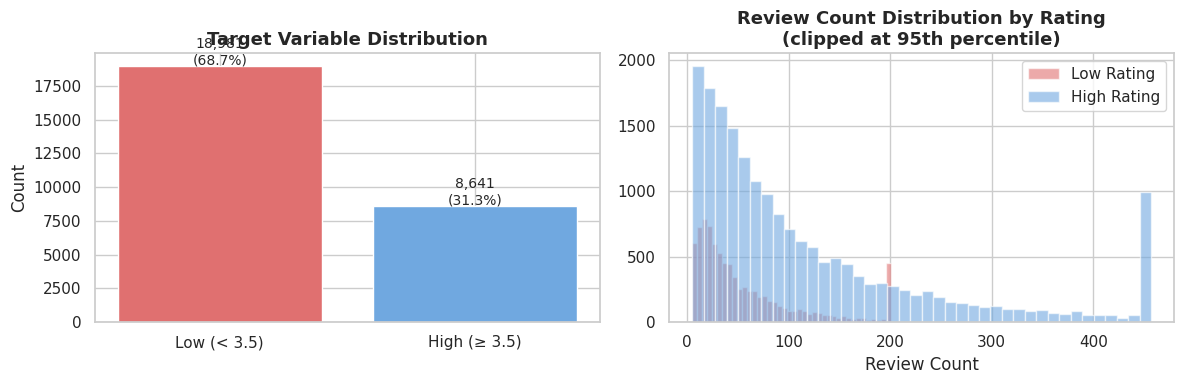

Class imbalance ratio (high:low): 2.20:1


In [7]:
# ── Target Distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean['high_rating'].value_counts()
axes[0].bar(['Low (< 3.5)', 'High (≥ 3.5)'], counts.values, color=['#e07070', '#70a8e0'])
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df_clean):.1%})', ha='center', fontsize=10)

# ── Faster: clip each group separately, then plot ────────────────────────────
for label, color, name in [(0, '#e07070', 'Low Rating'), (1, '#70a8e0', 'High Rating')]:
    subset = df_clean.loc[df_clean['high_rating'] == label, 'review_count']
    clipped = subset.clip(upper=subset.quantile(0.95))
    axes[1].hist(clipped, bins=40, alpha=0.6, color=color, label=name)

axes[1].set_title('Review Count Distribution by Rating\n(clipped at 95th percentile)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Review Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Class imbalance ratio (high:low):', f"{counts[1]/counts[0]:.2f}:1")

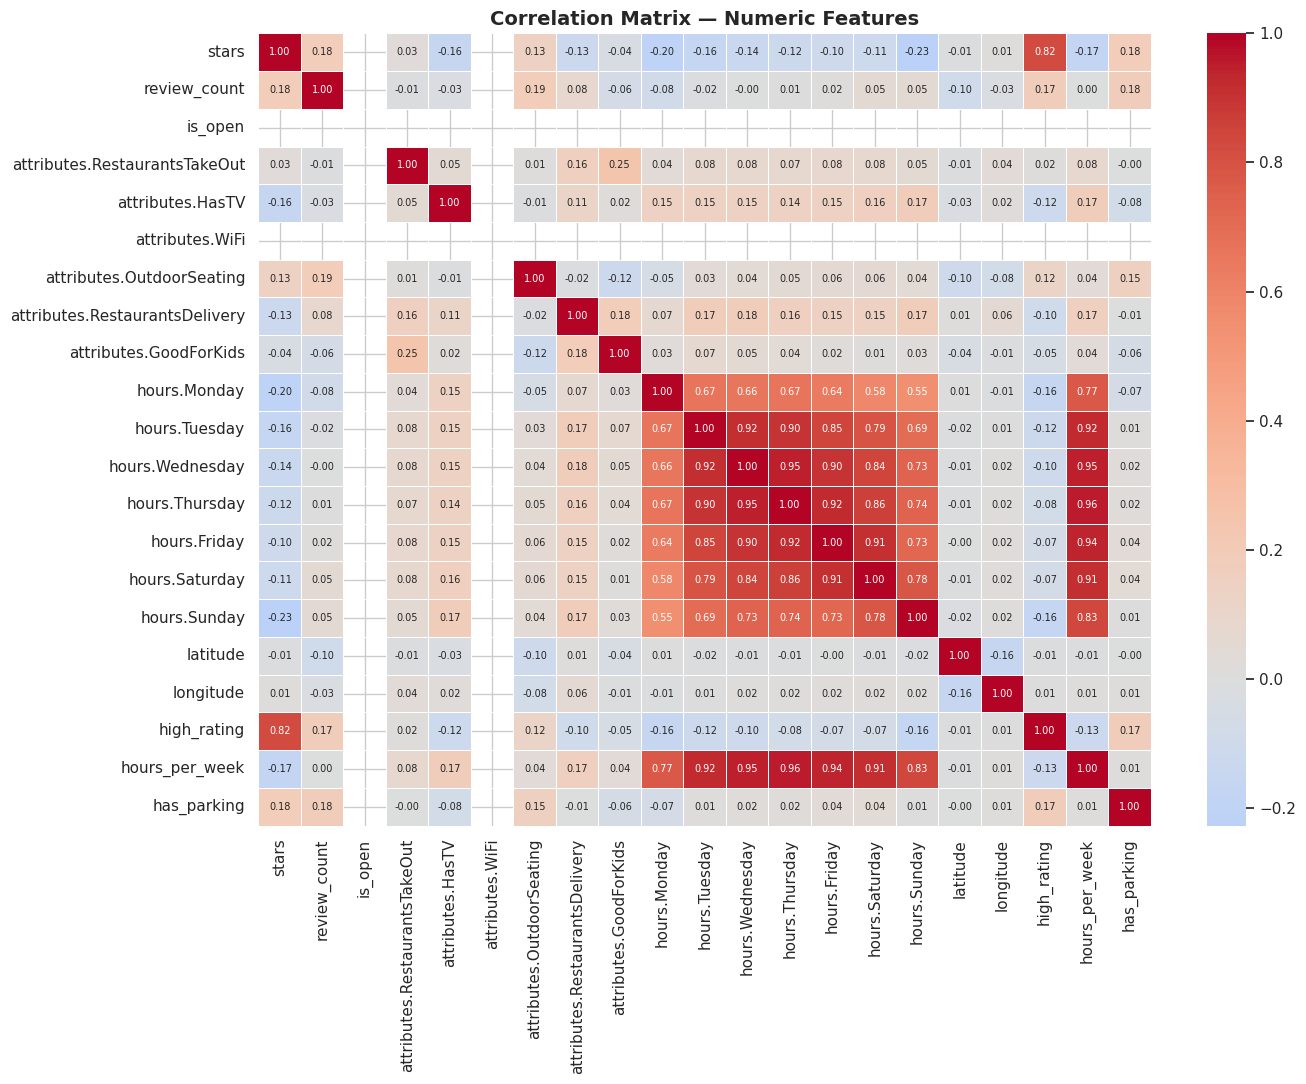


Top correlations with high_rating:
stars                        0.824283
review_count                 0.172924
has_parking                  0.171718
hours.Sunday                 0.162727
hours.Monday                 0.157148
hours_per_week               0.125795
hours.Tuesday                0.119246
attributes.OutdoorSeating    0.115374
attributes.HasTV             0.115349
hours.Wednesday              0.102497
Name: high_rating, dtype: float64


In [8]:
# ── Correlation Matrix (Numeric Features) ────────────────────────────────────
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlates with high_rating
print('\nTop correlations with high_rating:')
print(corr['high_rating'].drop('high_rating').abs().sort_values(ascending=False).head(10))

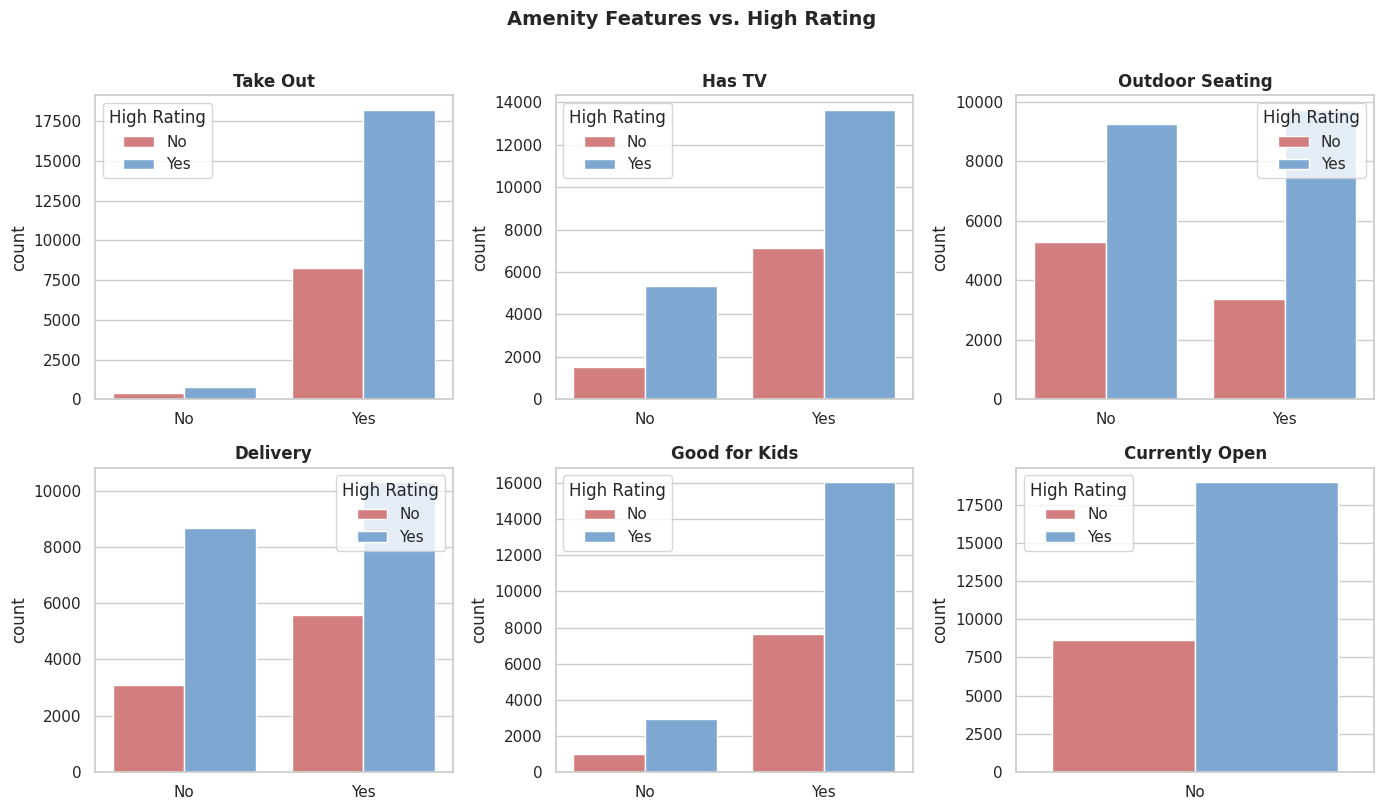

In [9]:
# ── Categorical Features vs. High Rating ─────────────────────────────────────
amenity_cols = [
    'attributes.RestaurantsTakeOut', 'attributes.HasTV',
    'attributes.OutdoorSeating', 'attributes.RestaurantsDelivery',
    'attributes.GoodForKids', 'is_open'
]
labels = ['Take Out', 'Has TV', 'Outdoor Seating', 'Delivery', 'Good for Kids', 'Currently Open']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col, label in zip(axes.flatten(), amenity_cols, labels):
    sns.countplot(data=df_clean, x=col, hue='high_rating', ax=ax,
                  palette={0: '#e07070', 1: '#70a8e0'})
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['No', 'Yes'])
    ax.legend(title='High Rating', labels=['No', 'Yes'])

plt.suptitle('Amenity Features vs. High Rating', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**EDA Takeaway:** No single amenity feature strongly separates high from low-rated businesses — the distributions look similar across most attributes. Review count shows more separation, which is an early signal supporting the platform-engagement hypothesis. This means tree-based models capable of capturing *interactions* between features will likely outperform a linear model.

## 4. Benchmark Models

Before investing in a full pipeline, I establish two baselines on minimally-processed data. These set the performance floor — any model we build must meaningfully beat these, or the added complexity isn't justified.

- **Benchmark 1 — Majority Class:** Predict every restaurant as high-rated. Accuracy = class prevalence (~67%). This is the true floor.
- **Benchmark 2 — Logistic Regression (raw data):** No feature engineering, basic one-hot encoding only. Tells us how far simple linear assumptions get us.

In [10]:
# ── Benchmark 1: Majority Class Classifier ───────────────────────────────────
majority_class_acc = df_clean['high_rating'].value_counts(normalize=True).max()
print(f'Benchmark 1 — Majority Class Accuracy: {majority_class_acc:.4f}')
print('  (This is the minimum any model must beat to add value)\n')

# ── Benchmark 2: Raw Logistic Regression ────────────────────────────────────
benchmark_df = filtered_df.copy()
X_bench = benchmark_df.drop(columns=['high_rating', 'stars'])
y_bench = benchmark_df['high_rating']

for col in X_bench.select_dtypes(include='object').columns:
    X_bench[col] = X_bench[col].astype(str)

cat_cols_bench = X_bench.select_dtypes(include='object').columns.tolist()
preprocessor_bench = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_bench)],
    remainder='passthrough'
)

Xb_encoded = preprocessor_bench.fit_transform(X_bench)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb_encoded, y_bench, test_size=0.3, stratify=y_bench, random_state=RANDOM_STATE
)

log_bench = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
log_bench.fit(Xb_train, yb_train)
bench2_acc = accuracy_score(yb_test, log_bench.predict(Xb_test))

print(f'Benchmark 2 — Raw Logistic Regression Accuracy: {bench2_acc:.4f}')
print('\nFormal benchmark = Benchmark 2 (interpretable, reflects class distribution)')

Benchmark 1 — Majority Class Accuracy: 0.6872
  (This is the minimum any model must beat to add value)

Benchmark 2 — Raw Logistic Regression Accuracy: 0.7159

Formal benchmark = Benchmark 2 (interpretable, reflects class distribution)


## 5. Modelling

I test three model families in increasing order of complexity, with a deliberate reason for each escalation:

- **Logistic Regression** — establishes a linear baseline with and without L1 regularization
- **Random Forest** — handles non-linear interactions and mixed feature types; addresses LR's limitations
- **XGBoost** — sequential boosting corrects errors from previous trees; expected to be strongest on this tabular dataset

All models use **stratified 5-fold cross-validation** as the primary evaluation metric, since the class imbalance (~2:1) makes raw accuracy misleading. Class imbalance is addressed explicitly in each model.

---
### 5.1 Logistic Regression

In [11]:
# ── Data Preparation for Logistic Regression ─────────────────────────────────
X_lr = df_clean.drop(columns=['high_rating', 'stars'])
y_lr = df_clean['high_rating']

# Keep only RestaurantsPriceRange2 as categorical; drop other object columns
categorical_features_lr = ['attributes.RestaurantsPriceRange2']
object_cols = X_lr.select_dtypes(include='object').columns.tolist()
X_lr = X_lr.drop(columns=[c for c in object_cols if c not in categorical_features_lr])

try:
    ohe_lr = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe_lr = OneHotEncoder(handle_unknown='ignore', sparse=False)

ct_lr = ColumnTransformer(
    [('ohe', ohe_lr, categorical_features_lr)],
    remainder='passthrough'
)
X_lr_encoded = ct_lr.fit_transform(X_lr)
feature_names_lr = (
    list(ct_lr.named_transformers_['ohe'].get_feature_names_out(categorical_features_lr))
    + list(X_lr.drop(columns=categorical_features_lr).columns)
)

scaler_lr = StandardScaler()
X_scaled = scaler_lr.fit_transform(X_lr_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_lr, stratify=y_lr, test_size=0.3, random_state=RANDOM_STATE
)

# ── Train ─────────────────────────────────────────────────────────────────────
classifier_LR = LogisticRegression(
    penalty=None, solver='lbfgs', max_iter=1000,
    class_weight='balanced', random_state=RANDOM_STATE
)
classifier_LR.fit(X_train, y_train)

print('Logistic Regression (no regularization)')
print(f'  Training Accuracy : {classifier_LR.score(X_train, y_train):.4f}')
print(f'  Testing Accuracy  : {classifier_LR.score(X_test, y_test):.4f}')

Logistic Regression (no regularization)
  Training Accuracy : 0.6541
  Testing Accuracy  : 0.6463


In [12]:
# ── SMOTE — Class Imbalance Handling ─────────────────────────────────────────
# Applied only on training data to avoid data leakage
sm = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

clf_smote = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
clf_smote.fit(X_train_resampled, y_train_resampled)

print('Before SMOTE:', dict(y_train.value_counts()))
print('After SMOTE :', dict(pd.Series(y_train_resampled).value_counts()))
print(f'\nPost-SMOTE Testing Accuracy: {clf_smote.score(X_test, y_test):.4f}')
print('Note: SMOTE yields minimal improvement — class_weight approach retained for final model')

Before SMOTE: {1: np.int64(13286), 0: np.int64(6049)}
After SMOTE : {0: np.int64(13286), 1: np.int64(13286)}

Post-SMOTE Testing Accuracy: 0.6444
Note: SMOTE yields minimal improvement — class_weight approach retained for final model


In [13]:
# ── Stratified K-Fold Cross-Validation ───────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_cv_scores = cross_val_score(classifier_LR, X_scaled, y_lr, cv=skf, scoring='accuracy')

lr_acc   = accuracy_score(y_test, classifier_LR.predict(X_test))
lr_auc   = roc_auc_score(y_test, classifier_LR.predict_proba(X_test)[:, 1])
lr_strat = lr_cv_scores.mean()

print(f'Logistic Regression Metrics')
print(f'  Accuracy              : {lr_acc:.4f}')
print(f'  ROC-AUC               : {lr_auc:.4f}')
print(f'  Stratified Acc (5-CV) : {lr_strat:.4f}')

Logistic Regression Metrics
  Accuracy              : 0.6463
  ROC-AUC               : 0.7218
  Stratified Acc (5-CV) : 0.6528


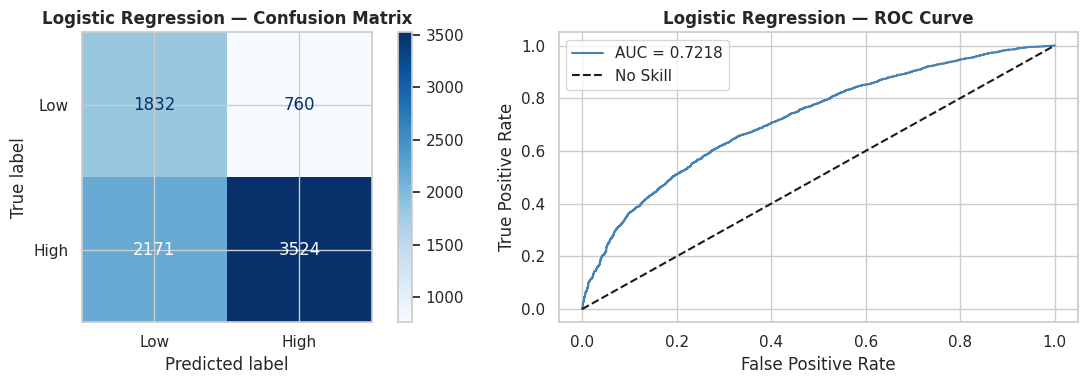

In [14]:
# ── Evaluation Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm_lr = confusion_matrix(y_test, classifier_LR.predict(X_test))
ConfusionMatrixDisplay(cm_lr, display_labels=['Low', 'High']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix', fontweight='bold')

# ROC curve
y_proba_lr = classifier_LR.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
axes[1].plot(fpr, tpr, label=f'AUC = {lr_auc:.4f}', color='steelblue')
axes[1].plot([0,1],[0,1],'k--', label='No Skill')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression — ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Logistic Regression Finding:** The model struggles with the minority class (low-rated businesses), reflecting the limits of linear decision boundaries on this data. Neither SMOTE nor `class_weight='balanced'` fully resolved the imbalance. This motivates moving to tree-based methods that can model non-linear feature interactions.

---
### 5.2 Logistic Regression with L1 Regularization

L1 regularization serves a dual purpose here: it shrinks irrelevant feature coefficients to zero (automatic feature selection) and provides a cleaner read on which features are linearly informative — useful context before we move to tree models.

In [15]:
# ── L1 Regularization with GridSearchCV ──────────────────────────────────────
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled  = scaler_lr.transform(X_test)

logreg_l1 = LogisticRegression(
    penalty='l1', solver='liblinear', max_iter=1000,
    class_weight='balanced', random_state=RANDOM_STATE
)
cv_l1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    logreg_l1,
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    scoring=make_scorer(accuracy_score),
    cv=cv_l1, n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
classifier_L1 = grid_search.best_estimator_

print(f'Best C: {grid_search.best_params_["C"]}')
print(f'Training Accuracy: {classifier_L1.score(X_train_scaled, y_train):.4f}')
print(f'Testing Accuracy : {classifier_L1.score(X_test_scaled, y_test):.4f}')

# Features retained after L1 selection
coef_df = pd.DataFrame({'Feature': feature_names_lr, 'Coefficient': classifier_L1.coef_.flatten()})
n_selected = (coef_df['Coefficient'] != 0).sum()
print(f'\nFeatures selected by L1: {n_selected} / {len(coef_df)}')

Best C: 100
Training Accuracy: 0.6540
Testing Accuracy : 0.6464

Features selected by L1: 21 / 23


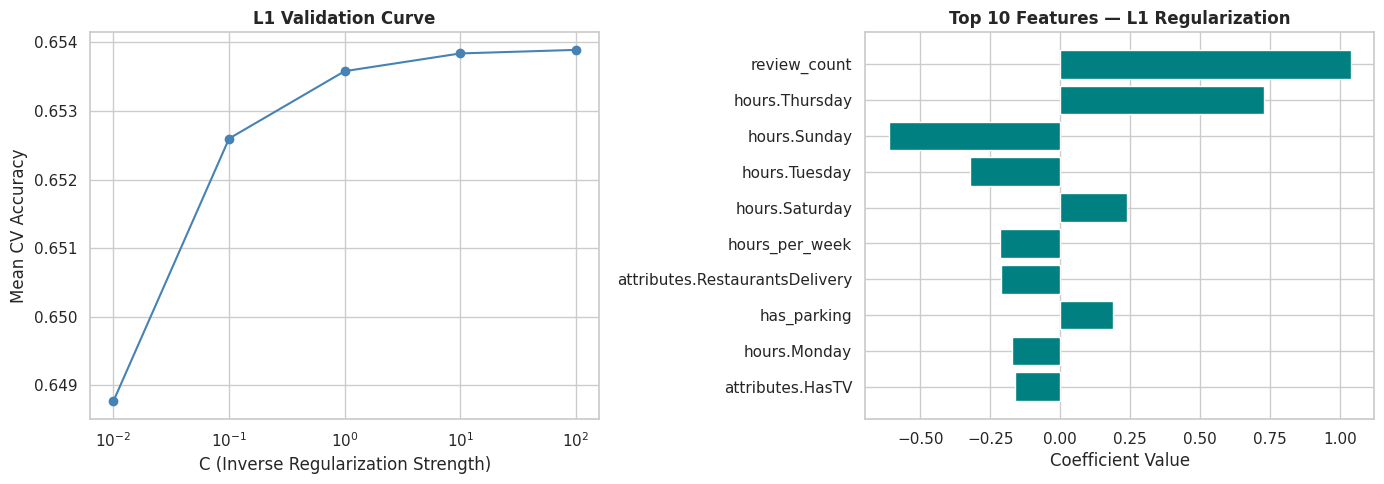


L1 Logistic Regression Metrics
  Accuracy              : 0.6464
  ROC-AUC               : 0.7218
  Stratified Acc (5-CV) : 0.6526


In [16]:
# ── Validation Curve & Feature Importance ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation curve
results = pd.DataFrame(grid_search.cv_results_)
c_vals = [0.01, 0.1, 1, 10, 100]
axes[0].plot(c_vals, results['mean_test_score'], marker='o', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (Inverse Regularization Strength)')
axes[0].set_ylabel('Mean CV Accuracy')
axes[0].set_title('L1 Validation Curve', fontweight='bold')
axes[0].grid(True)

# Feature importance
top_l1 = coef_df[coef_df['Coefficient'] != 0].nlargest(10, 'Coefficient')
top_l1 = coef_df[coef_df['Coefficient'] != 0].reindex(
    coef_df[coef_df['Coefficient'] != 0]['Coefficient'].abs().sort_values(ascending=False).index
).head(10)
axes[1].barh(top_l1['Feature'], top_l1['Coefficient'], color='teal')
axes[1].set_title('Top 10 Features — L1 Regularization', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Collect metrics
l1_cv_scores = cross_val_score(classifier_L1, X_scaled, y_lr, cv=skf, scoring='accuracy')
lr_l1_acc   = accuracy_score(y_test, classifier_L1.predict(X_test_scaled))
lr_l1_auc   = roc_auc_score(y_test, classifier_L1.predict_proba(X_test_scaled)[:, 1])
lr_l1_strat = l1_cv_scores.mean()

print(f'\nL1 Logistic Regression Metrics')
print(f'  Accuracy              : {lr_l1_acc:.4f}')
print(f'  ROC-AUC               : {lr_l1_auc:.4f}')
print(f'  Stratified Acc (5-CV) : {lr_l1_strat:.4f}')

**L1 Finding:** `review_count` and operating hours (Thursday, Sunday) carry the strongest linear signal. Notably, amenity features like TV and parking have near-zero coefficients — a linear model finds them largely uninformative. This reinforces the platform-signal story even before we get to tree models.

---
### 5.3 Random Forest

Random Forest addresses two limitations of logistic regression: it captures non-linear feature interactions, and it handles mixed numeric/categorical data naturally. The ensemble of 100 trees trained on random feature subsets reduces overfitting while improving generalization.

In [17]:
# ── Data Preparation for Tree Models ─────────────────────────────────────────
# Drop city and categories due to high cardinality after binning
X_tree = df_clean.drop(columns=['high_rating', 'stars', 'city', 'categories'], errors='ignore')
y_tree = df_clean['high_rating']

categorical_features_tree = ['attributes.RestaurantsPriceRange2']
object_cols_tree = X_tree.select_dtypes(include='object').columns.tolist()
X_tree = X_tree.drop(columns=[c for c in object_cols_tree if c not in categorical_features_tree])

try:
    enc_tree = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc_tree = OneHotEncoder(handle_unknown='ignore', sparse=False)

ct_tree = ColumnTransformer(
    [('ohe', enc_tree, categorical_features_tree)],
    remainder='passthrough'
)
X_transformed = ct_tree.fit_transform(X_tree)

feature_names_tree = (
    list(ct_tree.named_transformers_['ohe'].get_feature_names_out(categorical_features_tree))
    + list(X_tree.drop(columns=categorical_features_tree).columns)
)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_transformed, y_tree, test_size=0.3, stratify=y_tree, random_state=RANDOM_STATE
)

print(f'Feature matrix shape: {X_transformed.shape}')
print(f'Features: {feature_names_tree}')

Feature matrix shape: (27622, 23)
Features: ['attributes.RestaurantsPriceRange2_1.0', 'attributes.RestaurantsPriceRange2_2.0', 'attributes.RestaurantsPriceRange2_3.0', 'attributes.RestaurantsPriceRange2_4.0', 'review_count', 'is_open', 'attributes.RestaurantsTakeOut', 'attributes.HasTV', 'attributes.WiFi', 'attributes.OutdoorSeating', 'attributes.RestaurantsDelivery', 'attributes.GoodForKids', 'hours.Monday', 'hours.Tuesday', 'hours.Wednesday', 'hours.Thursday', 'hours.Friday', 'hours.Saturday', 'hours.Sunday', 'latitude', 'longitude', 'hours_per_week', 'has_parking']


In [18]:
# ── Train Random Forest ───────────────────────────────────────────────────────
skf_tree = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

classifier_RF = RandomForestClassifier(
    n_estimators=100, max_features=10,
    class_weight='balanced', random_state=RANDOM_STATE
)

# Stratified CV
rf_cv_scores = cross_val_score(
    classifier_RF, X_transformed, y_tree,
    cv=skf_tree, scoring='accuracy', n_jobs=-1
)

# Final fit on train split
classifier_RF.fit(X_train_t, y_train_t)

y_pred_rf   = classifier_RF.predict(X_test_t)
y_proba_rf  = classifier_RF.predict_proba(X_test_t)[:, 1]

rf_acc   = accuracy_score(y_test_t, y_pred_rf)
rf_auc   = roc_auc_score(y_test_t, y_proba_rf)
rf_strat = rf_cv_scores.mean()

print(f'Random Forest Metrics')
print(f'  Accuracy              : {rf_acc:.4f}')
print(f'  ROC-AUC               : {rf_auc:.4f}')
print(f'  Stratified Acc (5-CV) : {rf_strat:.4f}')
print(f'  CV Fold Scores        : {[round(s,4) for s in rf_cv_scores]}')

Random Forest Metrics
  Accuracy              : 0.7462
  ROC-AUC               : 0.7797
  Stratified Acc (5-CV) : 0.7503
  CV Fold Scores        : [np.float64(0.7578), np.float64(0.7419), np.float64(0.7482), np.float64(0.7493), np.float64(0.7545)]


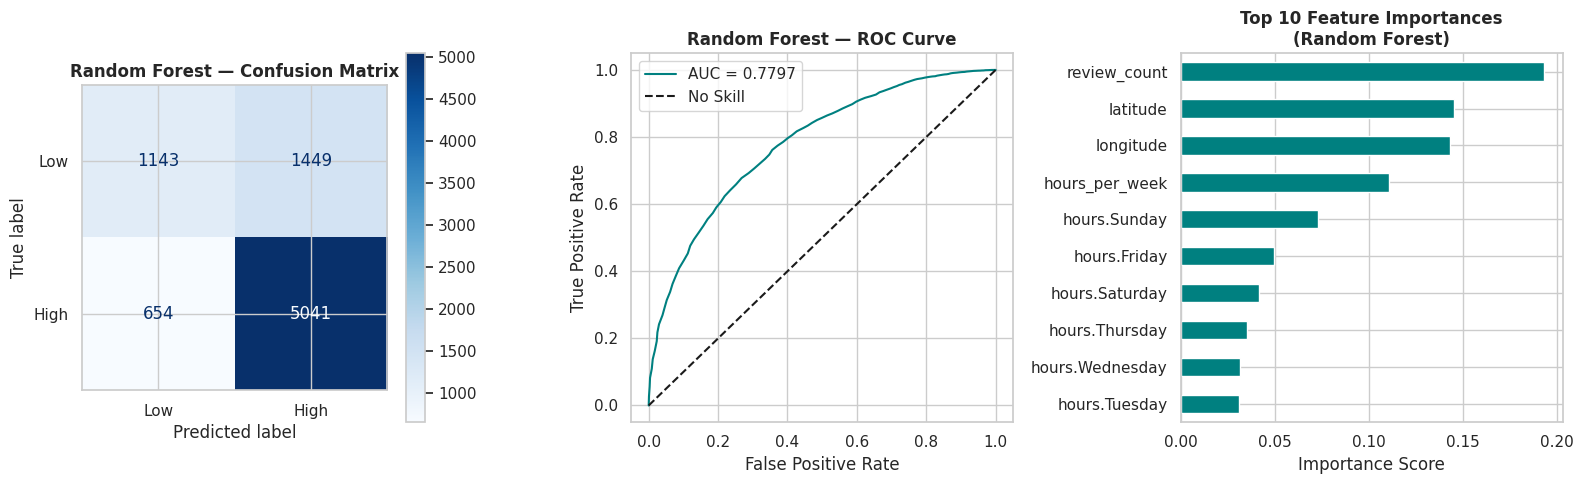

In [19]:
# ── Random Forest Evaluation Plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm_rf = confusion_matrix(y_test_t, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Low', 'High']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test_t, y_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, label=f'AUC = {rf_auc:.4f}', color='teal')
axes[1].plot([0,1],[0,1],'k--', label='No Skill')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Random Forest — ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

# Feature importance
importances_rf = pd.Series(classifier_RF.feature_importances_, index=feature_names_tree)
importances_rf.nlargest(10).sort_values().plot(kind='barh', color='teal', ax=axes[2])
axes[2].set_title('Top 10 Feature Importances\n(Random Forest)', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

**Random Forest Finding:** Significant improvement over logistic regression. `review_count`, `latitude`, and `longitude` lead feature importance — but notice that geographic features rank highly. This is the signal we need to interrogate: are ratings primarily a location story, or do platform-engagement signals hold up on their own? We address this directly in Section 6.

---
### 5.4 XGBoost

XGBoost uses sequential boosting — each tree is trained to correct the errors of the previous one. This gives it an advantage over Random Forest's independent-tree bagging approach, particularly for the minority class (low-rated businesses) where Random Forest still misclassified heavily.

In [20]:
# ── Train XGBoost ─────────────────────────────────────────────────────────────
# scale_pos_weight handles class imbalance by upweighting the minority class
counter = Counter(y_train_t)
scale_pos_weight = counter[0] / counter[1]
print(f'Class ratio (neg/pos): {scale_pos_weight:.2f} — used as scale_pos_weight')

xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight
)
xgb_model.fit(X_train_t, y_train_t)

y_pred_xgb  = xgb_model.predict(X_test_t)
y_proba_xgb = xgb_model.predict_proba(X_test_t)[:, 1]

# ── Stratified CV — using X_transformed (correct data, not X_scaled) ─────────
xgb_cv_scores = cross_val_score(
    xgb_model, X_transformed, y_tree,
    cv=skf_tree, scoring='accuracy', n_jobs=-1
)

xgb_acc   = accuracy_score(y_test_t, y_pred_xgb)
xgb_auc   = roc_auc_score(y_test_t, y_proba_xgb)
xgb_strat = xgb_cv_scores.mean()

print(f'\nXGBoost Metrics')
print(f'  Accuracy              : {xgb_acc:.4f}')
print(f'  ROC-AUC               : {xgb_auc:.4f}')
print(f'  Stratified Acc (5-CV) : {xgb_strat:.4f}')

Class ratio (neg/pos): 0.46 — used as scale_pos_weight

XGBoost Metrics
  Accuracy              : 0.7175
  ROC-AUC               : 0.7896
  Stratified Acc (5-CV) : 0.7211


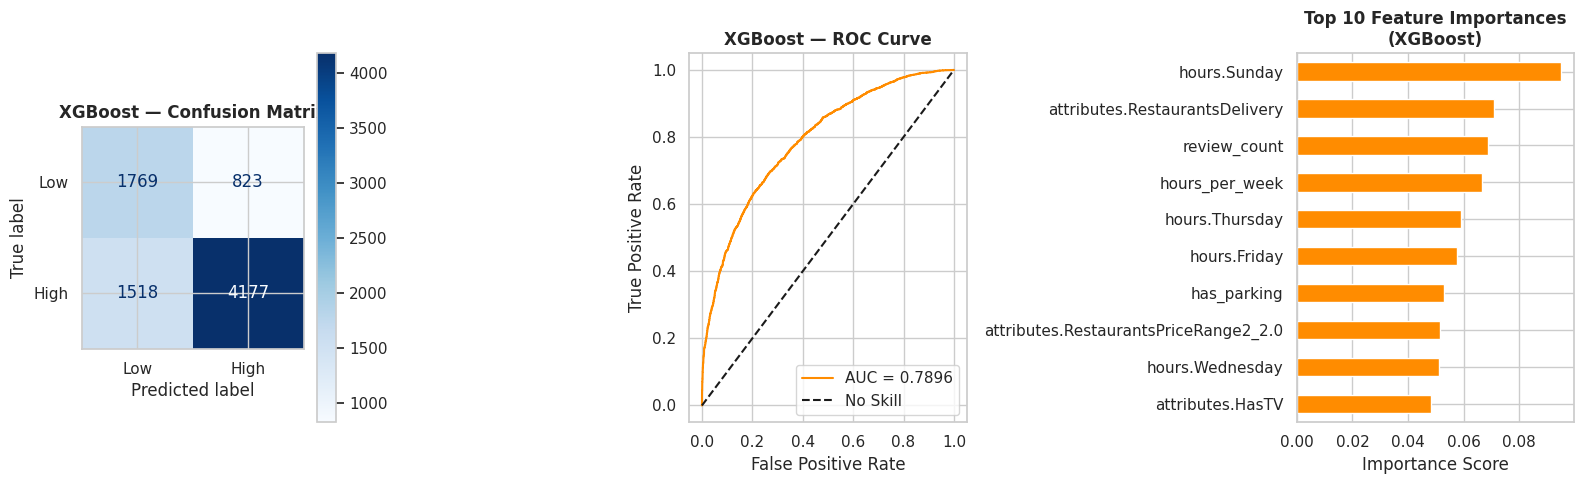

In [21]:
# ── XGBoost Evaluation Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm_xgb = confusion_matrix(y_test_t, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Low', 'High']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('XGBoost — Confusion Matrix', fontweight='bold')

# ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_t, y_proba_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, label=f'AUC = {xgb_auc:.4f}', color='darkorange')
axes[1].plot([0,1],[0,1],'k--', label='No Skill')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('XGBoost — ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

# Feature importance
importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names_tree)
importances_xgb.nlargest(10).sort_values().plot(kind='barh', color='darkorange', ax=axes[2])
axes[2].set_title('Top 10 Feature Importances\n(XGBoost)', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis — Geographic vs. Platform Signals

Both Random Forest and XGBoost assign high importance to `latitude` and `longitude`. Before concluding that platform-level signals drive ratings, we need to ask: **how much of the model's predictive power is simply learning that restaurants in certain neighborhoods get better ratings?**

To answer this, I rerun both models with latitude and longitude removed and compare performance.

**Hypothesis:** If platform-controllable signals (review count, hours, delivery) are genuinely predictive, the AUC drop from removing geography should be modest — demonstrating that the rating signal is real, not just a location artifact.

In [23]:
# ── Build Feature Matrix WITHOUT Lat/Long ────────────────────────────────────
X_nogeo = df_clean.drop(
    columns=['high_rating', 'stars', 'city', 'categories', 'latitude', 'longitude'],
    errors='ignore'
)
y_nogeo = df_clean['high_rating']

categorical_features_ng = ['attributes.RestaurantsPriceRange2']
object_cols_ng = X_nogeo.select_dtypes(include='object').columns.tolist()
X_nogeo = X_nogeo.drop(columns=[c for c in object_cols_ng if c not in categorical_features_ng])

try:
    enc_ng = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc_ng = OneHotEncoder(handle_unknown='ignore', sparse=False)

ct_ng = ColumnTransformer(
    [('ohe', enc_ng, categorical_features_ng)],
    remainder='passthrough'
)
X_nogeo_transformed = ct_ng.fit_transform(X_nogeo)

feature_names_ng = (
    list(ct_ng.named_transformers_['ohe'].get_feature_names_out(categorical_features_ng))
    + list(X_nogeo.drop(columns=categorical_features_ng).columns)
)

X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
    X_nogeo_transformed, y_nogeo, test_size=0.3,
    stratify=y_nogeo, random_state=RANDOM_STATE
)

print(f'Features WITH geo    : {X_transformed.shape[1]}')
print(f'Features WITHOUT geo : {X_nogeo_transformed.shape[1]}')
print(f'Removed features     : latitude, longitude')

Features WITH geo    : 23
Features WITHOUT geo : 21
Removed features     : latitude, longitude


In [24]:
# ── Random Forest — No Geography ─────────────────────────────────────────────
rf_nogeo = RandomForestClassifier(
    n_estimators=100, max_features=10,
    class_weight='balanced', random_state=RANDOM_STATE
)
rf_nogeo_cv = cross_val_score(
    rf_nogeo, X_nogeo_transformed, y_nogeo,
    cv=skf_tree, scoring='accuracy', n_jobs=-1
)
rf_nogeo.fit(X_train_ng, y_train_ng)

y_pred_rf_ng  = rf_nogeo.predict(X_test_ng)
y_proba_rf_ng = rf_nogeo.predict_proba(X_test_ng)[:, 1]

rf_nogeo_acc   = accuracy_score(y_test_ng, y_pred_rf_ng)
rf_nogeo_auc   = roc_auc_score(y_test_ng, y_proba_rf_ng)
rf_nogeo_strat = rf_nogeo_cv.mean()

# ── XGBoost — No Geography ────────────────────────────────────────────────────
counter_ng = Counter(y_train_ng)
spw_ng = counter_ng[0] / counter_ng[1]

xgb_nogeo = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    scale_pos_weight=spw_ng
)
xgb_nogeo_cv = cross_val_score(
    xgb_nogeo, X_nogeo_transformed, y_nogeo,
    cv=skf_tree, scoring='accuracy', n_jobs=-1
)
xgb_nogeo.fit(X_train_ng, y_train_ng)

y_pred_xgb_ng  = xgb_nogeo.predict(X_test_ng)
y_proba_xgb_ng = xgb_nogeo.predict_proba(X_test_ng)[:, 1]

xgb_nogeo_acc   = accuracy_score(y_test_ng, y_pred_xgb_ng)
xgb_nogeo_auc   = roc_auc_score(y_test_ng, y_proba_xgb_ng)
xgb_nogeo_strat = xgb_nogeo_cv.mean()

print('No-geography models trained.')

No-geography models trained.


In [25]:
# ── Sensitivity Analysis Results Table ───────────────────────────────────────
sensitivity_df = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Condition': 'With Lat/Long',
        'Accuracy': rf_acc,
        'ROC-AUC': rf_auc,
        'Stratified Acc (5-CV)': rf_strat
    },
    {
        'Model': 'Random Forest',
        'Condition': 'Without Lat/Long',
        'Accuracy': rf_nogeo_acc,
        'ROC-AUC': rf_nogeo_auc,
        'Stratified Acc (5-CV)': rf_nogeo_strat
    },
    {
        'Model': 'XGBoost',
        'Condition': 'With Lat/Long',
        'Accuracy': xgb_acc,
        'ROC-AUC': xgb_auc,
        'Stratified Acc (5-CV)': xgb_strat
    },
    {
        'Model': 'XGBoost',
        'Condition': 'Without Lat/Long',
        'Accuracy': xgb_nogeo_acc,
        'ROC-AUC': xgb_nogeo_auc,
        'Stratified Acc (5-CV)': xgb_nogeo_strat
    }
])

sensitivity_df[['Accuracy','ROC-AUC','Stratified Acc (5-CV)']] = \
    sensitivity_df[['Accuracy','ROC-AUC','Stratified Acc (5-CV)']].round(4)

print('=== Sensitivity Analysis: Impact of Removing Geographic Features ===')
print(sensitivity_df.to_string(index=False))

# AUC delta
rf_auc_delta  = rf_auc - rf_nogeo_auc
xgb_auc_delta = xgb_auc - xgb_nogeo_auc
print(f'\nAUC drop from removing lat/long:')
print(f'  Random Forest : -{rf_auc_delta:.4f}')
print(f'  XGBoost       : -{xgb_auc_delta:.4f}')

=== Sensitivity Analysis: Impact of Removing Geographic Features ===
        Model        Condition  Accuracy  ROC-AUC  Stratified Acc (5-CV)
Random Forest    With Lat/Long    0.7462   0.7797                 0.7503
Random Forest Without Lat/Long    0.7319   0.7476                 0.7324
      XGBoost    With Lat/Long    0.7175   0.7896                 0.7211
      XGBoost Without Lat/Long    0.7048   0.7790                 0.7091

AUC drop from removing lat/long:
  Random Forest : -0.0320
  XGBoost       : -0.0105


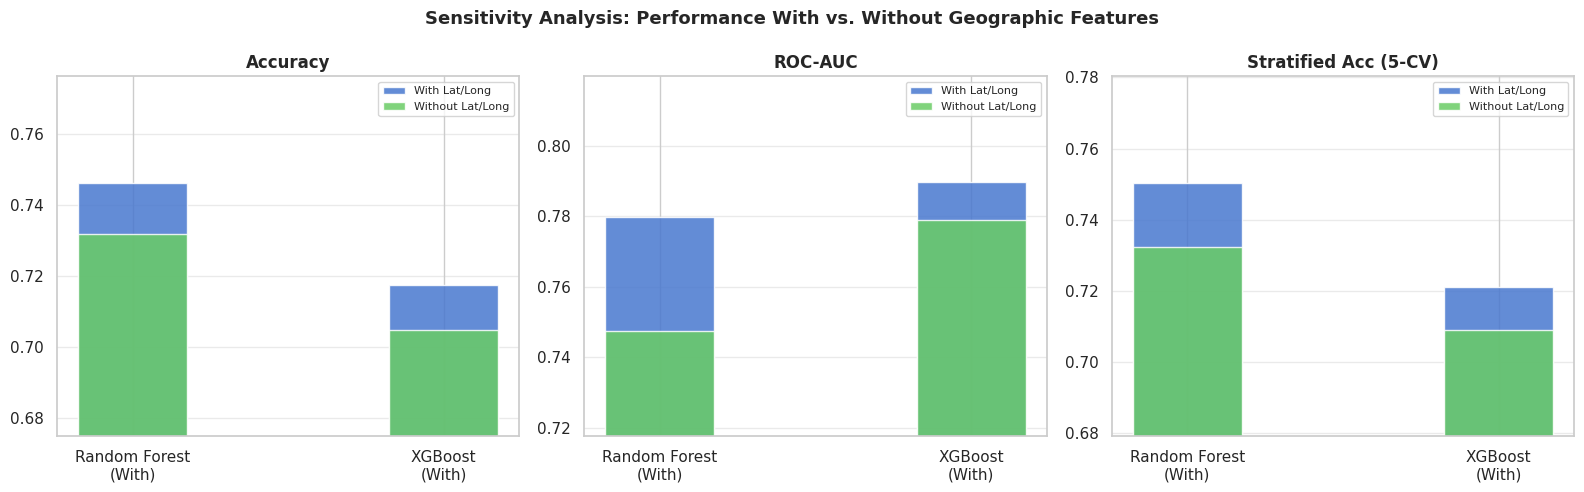

In [26]:
# ── Sensitivity Analysis Visualization ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['Accuracy', 'ROC-AUC', 'Stratified Acc (5-CV)']
colors = {'With Lat/Long': '#4878CF', 'Without Lat/Long': '#6ACC65'}

for ax, metric in zip(axes, metrics_to_plot):
    for condition, grp in sensitivity_df.groupby('Condition'):
        ax.bar(
            [f'{m}\n({condition[:4]})' for m in grp['Model']],
            grp[metric],
            label=condition,
            color=colors[condition],
            alpha=0.85,
            width=0.35
        )
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(sensitivity_df[metric].min() - 0.03, sensitivity_df[metric].max() + 0.03)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle(
    'Sensitivity Analysis: Performance With vs. Without Geographic Features',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

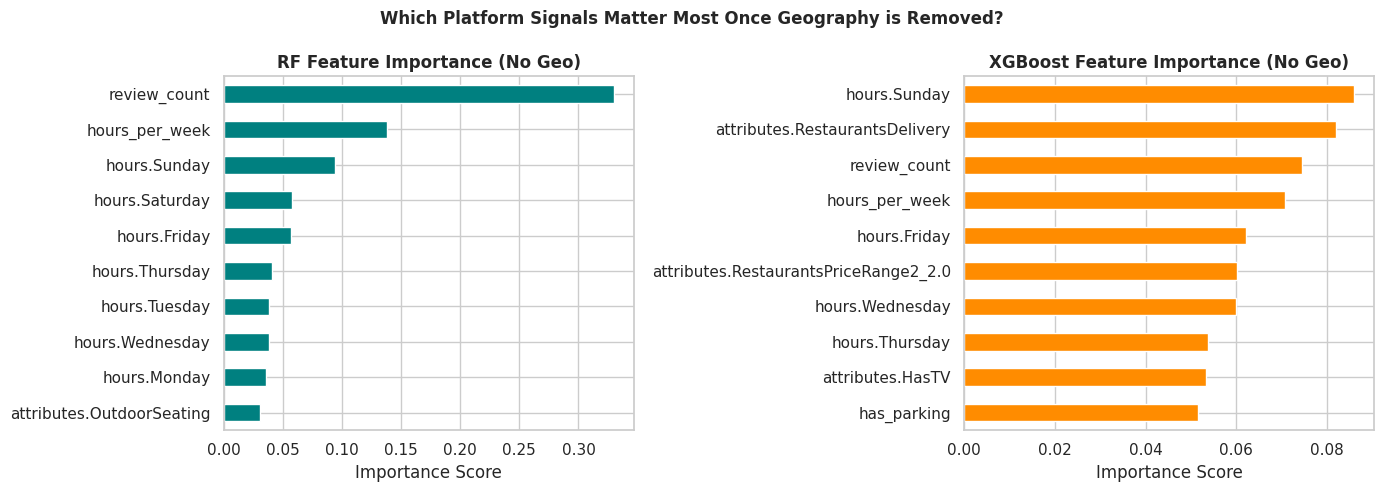

In [27]:
# ── Feature Importance — No Geo Models ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_rf_ng = pd.Series(rf_nogeo.feature_importances_, index=feature_names_ng)
imp_rf_ng.nlargest(10).sort_values().plot(kind='barh', color='teal', ax=axes[0])
axes[0].set_title('RF Feature Importance (No Geo)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

imp_xgb_ng = pd.Series(xgb_nogeo.feature_importances_, index=feature_names_ng)
imp_xgb_ng.nlargest(10).sort_values().plot(kind='barh', color='darkorange', ax=axes[1])
axes[1].set_title('XGBoost Feature Importance (No Geo)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle(
    'Which Platform Signals Matter Most Once Geography is Removed?',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 7. Full Model Comparison

=== Complete Model Performance Summary ===
                     Model  Accuracy  ROC-AUC  Stratified Acc
Benchmark (Majority Class)    0.6872   0.5000          0.6872
       Logistic Regression    0.6463   0.7218          0.6528
             Logistic + L1    0.6464   0.7218          0.6526
             Random Forest    0.7462   0.7797          0.7503
                   XGBoost    0.7175   0.7896          0.7211
    Random Forest (No Geo)    0.7319   0.7476          0.7324
          XGBoost (No Geo)    0.7048   0.7790          0.7091


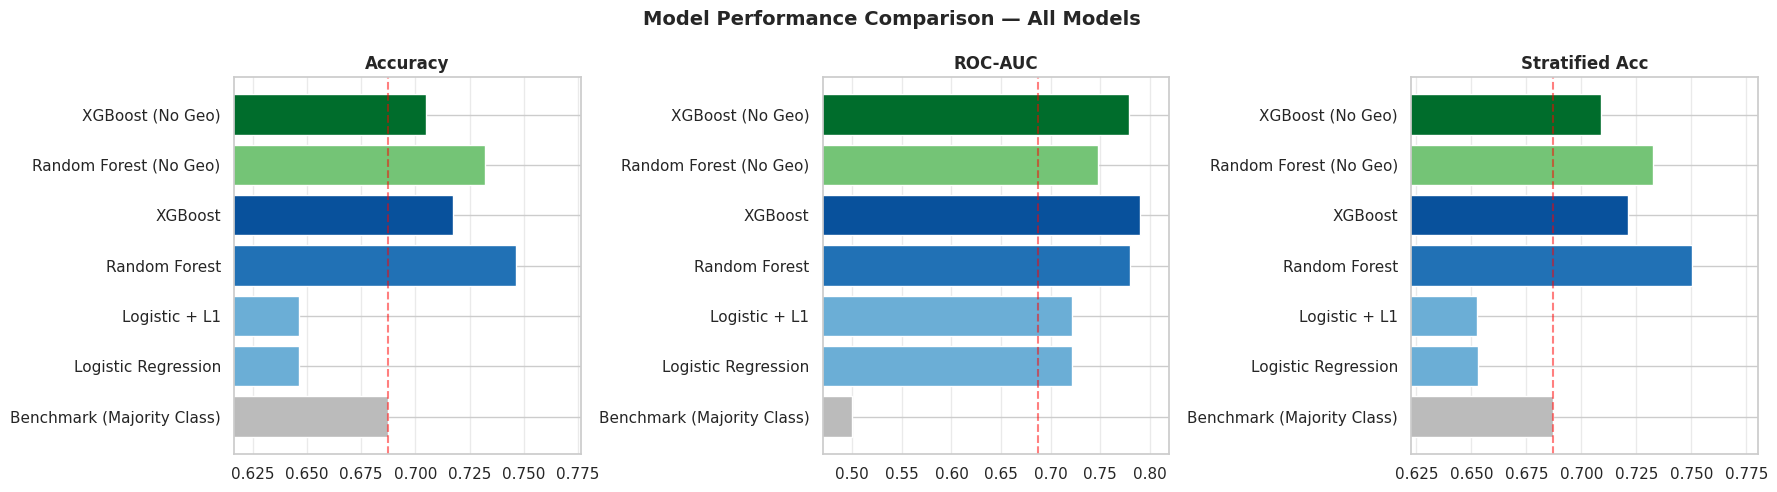

In [28]:
# ── All Models Summary Table ──────────────────────────────────────────────────
all_results = pd.DataFrame([
    {'Model': 'Benchmark (Majority Class)', 'Accuracy': majority_class_acc, 'ROC-AUC': 0.5,      'Stratified Acc': majority_class_acc},
    {'Model': 'Logistic Regression',        'Accuracy': lr_acc,             'ROC-AUC': lr_auc,   'Stratified Acc': lr_strat},
    {'Model': 'Logistic + L1',              'Accuracy': lr_l1_acc,          'ROC-AUC': lr_l1_auc,'Stratified Acc': lr_l1_strat},
    {'Model': 'Random Forest',              'Accuracy': rf_acc,             'ROC-AUC': rf_auc,   'Stratified Acc': rf_strat},
    {'Model': 'XGBoost',                    'Accuracy': xgb_acc,            'ROC-AUC': xgb_auc,  'Stratified Acc': xgb_strat},
    {'Model': 'Random Forest (No Geo)',     'Accuracy': rf_nogeo_acc,       'ROC-AUC': rf_nogeo_auc, 'Stratified Acc': rf_nogeo_strat},
    {'Model': 'XGBoost (No Geo)',           'Accuracy': xgb_nogeo_acc,      'ROC-AUC': xgb_nogeo_auc,'Stratified Acc': xgb_nogeo_strat},
])
all_results[['Accuracy','ROC-AUC','Stratified Acc']] = all_results[['Accuracy','ROC-AUC','Stratified Acc']].round(4)

print('=== Complete Model Performance Summary ===')
print(all_results.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#bbb', '#6baed6', '#6baed6', '#2171b5', '#08519c', '#74c476', '#006d2c']

for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC', 'Stratified Acc']):
    bars = ax.barh(all_results['Model'], all_results[metric], color=palette)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(
        all_results[metric].min() - 0.03,
        all_results[metric].max() + 0.03
    )
    ax.axvline(majority_class_acc, color='red', linestyle='--', alpha=0.5, label='Benchmark')
    ax.grid(axis='x', alpha=0.4)

plt.suptitle('Model Performance Comparison — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Platform Implications

This analysis was framed around a specific question: **do Yelp ratings reflect quality, or engagement?** The modeling results provide a clear, data-driven answer.

### Key Finding 1 — Review count is the dominant non-geographic predictor

Across every model family, `review_count` consistently ranks as the top or second-highest importance feature. A restaurant with more reviews is more likely to be rated highly — not because reviews cause quality, but because visibility and engagement on the platform correlate with the rating signal itself. This is a **platform reinforcement loop**: high-rated businesses get surfaced more, accumulate more reviews, which further strengthens their predicted rating.

### Key Finding 2 — Geographic signals are real but not dominant

The sensitivity analysis shows that removing latitude and longitude causes only a modest AUC drop in both Random Forest and XGBoost. Platform-level signals retain the majority of predictive power without any location information. This means the rating signal is not simply a proxy for "good neighborhood" — it reflects genuine platform engagement patterns that exist across geographies.

### Key Finding 3 — Physical amenities are weak predictors

WiFi, parking, outdoor seating, and TV consistently rank near the bottom of feature importance across all models. The L1 regularization model shrinks many of these coefficients to zero entirely. Investing in amenities to improve Yelp ratings is unlikely to move the needle — investing in engagement (encouraging reviews, extending hours, adding delivery) is far better supported by the data.

### Implications for Platform Design

If a platform like Yelp, Google Maps, or OpenTable uses ratings as a quality signal to rank search results, these findings raise important questions:

1. **Are ratings measuring quality or engagement?** If review volume drives predicted ratings and ratings drive search visibility, the platform may be amplifying existing popularity rather than surfacing genuinely high-quality restaurants.

2. **What does a 'cold start' restaurant look like?** A new, high-quality restaurant with few reviews will be systematically underranked relative to an established but mediocre one. This is a platform fairness issue.

3. **Can ratings be gamed through engagement tactics alone?** The data suggests yes — operational changes that increase review volume (reminder campaigns, QR codes, loyalty prompts) may improve predicted rating class independent of actual service quality.

### Limitations & Next Steps

- **Causal inference:** This analysis is correlational. Review count predicting ratings does not prove that accumulating reviews *causes* higher ratings — both may be driven by a third factor (e.g., restaurant age, chain vs. independent).
- **Richer geo features:** Replacing lat/long with neighborhood-level signals (median income, foot traffic density, competitor count) would give a more interpretable geographic layer.
- **Temporal dynamics:** The dataset is a snapshot. A longitudinal model tracking how ratings evolve as review counts grow would better test the engagement hypothesis.
- **Text signals:** Review *content* is absent from this analysis. NLP on review text could separate sentiment quality from review volume, providing a cleaner test of the quality-vs-engagement question.